In [ ]:
from torch.utils.data import Dataset
import torch.nn as nn
from glob import glob
import albumentations as A
from typing import Any, Dict, List
from matplotlib.path import Path
from typing import Dict, Any, List
import cv2
import torch
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader, random_split
from torch import optim
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score
from typing import Any, Dict, List
from random import Random
from pathlib import Path

# Задача 8. Компьютерное зрение: задача сегментации

* **Дедлайн**: 18.04.2025, 23:59
* **Основной полный балл**: 5
* **Максимум баллов**: 10

## Задача

Обучаем Сегментацию:
- https://colab.research.google.com/drive/1eUIOnLFB_9_6CJ3dVZxY9TV_gCqDAmaV?authuser=1#scrollTo=SjKfL5X_RbzH --- тут мы обучали на большом датасете одну эпоху.
- https://drive.google.com/file/d/11wp4Bm-hEVwmZq8GmqbLpKpJiqvDSNAe/view?usp=sharing --- тут лежит датасет который мы будем использовать.

Мы хотим обучить наш unet на небольшом датасете. Нужно заполнить репорт и сделать выводы.
Чтобы успеть сделать много экспериментов нужна видеокарта. Можно использовать colab, тут есть бесплатные gpu ресурсы --- так будет быстрее.


- Сделать train/test split (или кросс-валидацию), зафиксировать все сиды чтобы более-менее воспроизводились результаты. Добавить метрику **jaccard index**. Переобучиться на одном батче (например 4 картинки), попробовать получить почти идеальное качество, посмотреть получилось или нет. Посчитать метрики для батча и для теста. Обучить на всем train, построить train/val кривые для loss и для **jaccard index**, подобрать оптимальное время обучения (количество шагов) для фиксированных параметров. Визуализировать topN самых плохих предсказаний.
- Попробовать улучшить качество не меняя архитектуру: аугментации, гиперпараметры. Сделать test time аугментации через horizontal flip, посмотреть улучшается ли что-то.
- Попробовать улучшить качество изменяя архитектуру.
- (**+2 балла**) Сделать train/test разбиение. Внутри train сделать 5fold, обучить 5 моделей. Построить кривые обучения для каждого фолда. Предсказать тест со всех 5 моделей и сагрегировать предсказания (до расчета метрик), сравнить с одной моделью обученной на всех данных. Сравнить с моделями обученными на фолдах. Сравнить плохие предсказания теста на разных фолдах. Ошибается на одних и тех же семплах или на разных?

In [ ]:
assert torch.cuda.is_available()

# Датасет

Был взят предложенный датасет.

In [3]:
DATASET = "./dataset"
RANDOM_SEED = 42
DATA_SUBSET_SIZE = 100
TRAIN_RATIO = 0.8
BATCH_SIZE = 32
NUM_WORKERS = 2

train_size = int(TRAIN_RATIO * DATA_SUBSET_SIZE)
test_size = DATA_SUBSET_SIZE - train_size

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

In [ ]:
class PeopleDataset(Dataset):
    _MASK_TP = np.uint8
    _IMG_TP = np.float32

    def __init__(self, dataset_path: str, transform = None):
        self.image_paths = (glob(str(Path(dataset_path)/"images"/"*.jpg")))
        self.mask_paths = (glob(str(Path(dataset_path)/"masks"/"*.png")))
        self.transform = transform
        self.target_size = (256, 256)

    def __len__(self) -> int:
        return len(self.image_paths)

    def __getitem__(self, idx) -> Dict[str, Any] | List[Dict[str, Any]]:
        if isinstance(idx, slice):
            return [self[i] for i in range(*idx.indices(len(self)))]
        
        image = self._load_image(self.image_paths[idx])
        mask = self._load_mask(self.mask_paths[idx])
        
        if self.transform:
            augmented = self.transform(
                image=image.astype(self._IMG_TP),
                mask=mask.astype(self._MASK_TP)
            )
            image, mask = augmented['image'], augmented['mask']

        return {
            "image": torch.tensor(image.transpose(2, 0, 1)), 
            "mask": torch.tensor(mask, dtype=torch.long)[None, ...]
        }

    def _load_image(self, path: str) -> np.ndarray:
        image = cv2.imread(path, cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        return (cv2.resize(image, self.target_size) / 255.0).astype(self._IMG_TP)

    def _load_mask(self, path: str) -> np.ndarray:
        mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, self.target_size) > 100
        return mask.astype(self._MASK_TP)

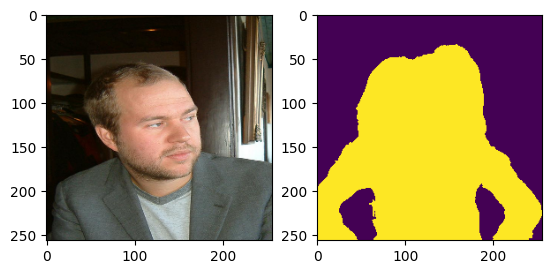

In [ ]:
data = PeopleDataset(DATASET)
_, axarr = plt.subplots(1,2)
axarr[0].imshow(data[12]["image"].permute(1, 2, 0))
axarr[1].imshow(data[12]["mask"].permute(1, 2, 0))

plt.show()

# U-NET

In [83]:
class CNNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=0):
        super(CNNBlock, self).__init__()
        self.seq_block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.seq_block(x)

class CNNBlocks(nn.Module):
    def __init__(self, n_conv, in_channels, out_channels, padding):
        super(CNNBlocks, self).__init__()
        self.layers = nn.ModuleList()
        for _ in range(n_conv):
            self.layers.append(CNNBlock(in_channels, out_channels, padding=padding))
            in_channels = out_channels

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

class Encoder(nn.Module):
    def __init__(self, in_channels, out_channels, padding, n_down=4):
        super(Encoder, self).__init__()
        self.enc_layers = nn.ModuleList()
        for _ in range(n_down):
            self.enc_layers.extend([
                CNNBlocks(n_conv=2, in_channels=in_channels, out_channels=out_channels, padding=padding),
                nn.MaxPool2d(2, 2)
            ])
            in_channels = out_channels
            out_channels *= 2

        self.enc_layers.append(CNNBlocks(n_conv=2, in_channels=in_channels, out_channels=out_channels, padding=padding))

    def forward(self, x):
        connections = []
        for layer in self.enc_layers:
            x = layer(x)
            if isinstance(layer, CNNBlocks):
                connections.append(x)

        return x, connections

class Decoder(nn.Module):
    def __init__(self, in_channels, out_channels, exit_channels, padding, n_up=4):
        super(Decoder, self).__init__()
        self.exit_channels = exit_channels
        self.layers = nn.ModuleList()

        for _ in range(n_up):
            self.layers.extend([
                nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2),
                CNNBlocks(n_conv=2, in_channels=in_channels, out_channels=out_channels, padding=padding)
            ])
            in_channels //= 2
            out_channels //= 2

        self.layers.append(nn.Conv2d(in_channels, self.exit_channels, kernel_size=1, padding=0))

    def forward(self, x, connections):
        connections.pop(-1)
        for layer in self.layers:
            if isinstance(layer, CNNBlocks):
                connections_current = connections.pop(-1)
                dim_4 = connections_current.size(3) - x.size(3)
                dim_3 = connections_current.size(2) - x.size(2)
                if dim_4 != 0 or dim_3 != 0:
                    x = nn.functional.pad(x, [0, dim_4, 0, dim_3])
                x = torch.cat([x, connections_current], dim=1)

            x = layer(x)
        return x

class UNET(nn.Module):
    def __init__(self, in_channels, first_out_channels, exit_channels, n_down=4, padding=1):
        super(UNET, self).__init__()
        self.encoder = Encoder(in_channels, first_out_channels, padding=padding, n_down=n_down)
        self.decoder = Decoder(first_out_channels * (2 ** n_down),
                               first_out_channels * (2 ** (n_down - 1)),
                               exit_channels, padding=padding, n_up=n_down)

    def forward(self, x):
        enc_out, connections = self.encoder(x)
        return self.decoder(enc_out, connections)

# Разделение датасета

In [84]:
dataset_subset = data[:DATA_SUBSET_SIZE]

train_data, test_data = random_split(
    dataset_subset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(RANDOM_SEED)
)

loader_config = {
    'batch_size': BATCH_SIZE,
    'num_workers': NUM_WORKERS,
    'pin_memory': True
}

train_loader = DataLoader(train_data, shuffle=True, **loader_config)
test_loader = DataLoader(test_data, shuffle=False, **loader_config) 

# Обучение

Обучение модели на части датасета и предворительный просмотр метрик.

In [ ]:
net = UNET(3, 16, 1)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(net.parameters(), lr=3e-4)

net = net.cuda().float()

torch.cuda.empty_cache()

for epoch in tqdm(range(10)):
    for i, data in enumerate(train_loader, 0):
        x = data['image']
        y = data['mask']

        optimizer.zero_grad()
        outputs = net(x.cuda().float())

        loss = criterion(outputs, y.cuda().float())
        loss.backward()
        optimizer.step()

In [ ]:
def show_prediction(net, test_loader):
    net.eval()
    device = next(net.parameters()).device
    
    with torch.no_grad():
        data = next(iter(test_loader))
        x = data['image'].to(device).float()
        y = data['mask']
        
        pred = net(x)
        pred_np = pred[0][0].sigmoid().cpu().numpy() > 0.5
        
        fig, axes = plt.subplots(1, 3, figsize=(10, 5))
        titles = ['Prediction', 'Mask', 'Image']
        displays = [pred_np, y[0][0].cpu().numpy(), x[0].permute(1, 2, 0).cpu().numpy()]
        
        for ax, title, img in zip(axes, titles, displays):
            ax.imshow(img.squeeze() if img.ndim == 3 else img, cmap='gray')
            ax.set_title(title)
            ax.axis('off')
        
        plt.tight_layout()
        plt.show()

def jaccard_index(preds, targets, threshold=0.5):
    preds = torch.sigmoid(preds)
    preds = (preds > threshold).float()
    intersection = (preds * targets).sum(dim=(1, 2, 3))
    union = (preds + targets - preds * targets).sum(dim=(1, 2, 3))
    return (intersection / (union + 1e-8)).mean().item()

def _calculate_metric(net, loader, metric_fn):
    net.eval()
    device = next(net.parameters()).device
    total_score = 0.0
    total_items = 0
    
    with torch.no_grad():
        for data in loader:
            x = data['image'].to(device).float()
            y = data['mask'].to(device).float()
            
            preds = net(x)
            batch_size = x.size(0)
            
            if metric_fn == jaccard_index:
                score = metric_fn(preds, y)
                total_score += score * batch_size
            else:
                preds = (preds.sigmoid() > 0.5).float()
                preds_flat = preds.view(batch_size, -1).cpu().numpy()
                y_flat = y.view(batch_size, -1).cpu().numpy()
                total_score += sum(metric_fn(y_true, y_pred) 
                             for y_true, y_pred in zip(y_flat, preds_flat))
            
            total_items += batch_size
    
    return total_score / total_items if total_items > 0 else 0.0

def accuracy(net, loader):
    return _calculate_metric(net, loader, accuracy_score)

def jaccard_index_metric(net, loader):
    return _calculate_metric(net, loader, jaccard_index)

def calc_loss(net, loader, criterion):
    net.eval()
    device = next(net.parameters()).device
    total_loss = 0.0
    total_items = 0
    
    with torch.no_grad():
        for data in loader:
            x = data['image'].to(device).float()
            y = data['mask'].to(device).float()
            
            preds = net(x).sigmoid()
            batch_size = x.size(0)
            
            total_loss += criterion(preds, y).item() * batch_size
            total_items += batch_size
    
    return total_loss / total_items if total_items > 0 else float('inf')

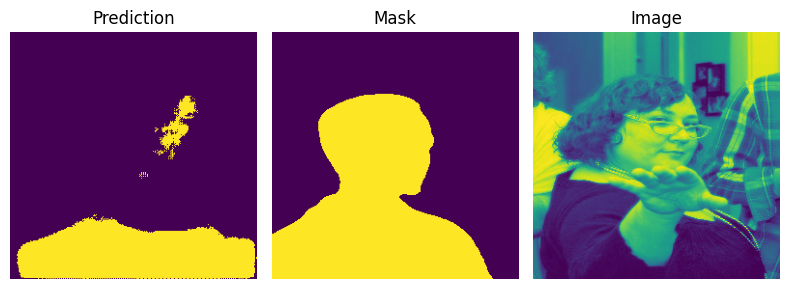

Jaccard index: 0.2331382379105344
Accuracy: 0.6293937683105468


In [ ]:
show_prediction(net, test_loader)
print(f"Jaccard index: {jaccard_index(net, test_loader)}")
print(f"Accuracy: {accuracy(net, test_loader)}")

# Переобучение модели

Попытаемся переобучить модель на одном батче (5 картинок)

In [94]:
train, test = random_split(dataset_subset, [5, 95], generator=torch.Generator().manual_seed(RANDOM_SEED))
train_loader = DataLoader(train, batch_size=8, shuffle=True, num_workers=2)
test_loader = DataLoader(test, batch_size=8, shuffle=False, num_workers=2)

print(f"Train: {len(train)}\nTest: {len(test)}")

Train: 5
Test: 95


In [ ]:
net = UNET(3, 16, 1)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(net.parameters(), lr=3e-4)

net = net.cuda()

torch.cuda.empty_cache()

accuracy_dict = {"train": [], "test": []}
jaccard_dict = {"train": [], "test": []}
loss_dict = {"train": [], "test": []}

EPOCHS = 250

for epoch in tqdm(range(EPOCHS)):
    val_loss = 0.0
    for i, data in enumerate(train_loader, 0):
        x = data['image']
        y = data['mask']

        optimizer.zero_grad()
        outputs = net(x.cuda().float())

        loss = criterion(outputs, y.cuda().float())
        val_loss += loss.item()
        loss.backward()
        optimizer.step()

    accuracy_dict["train"].append(accuracy(net, train_loader))
    jaccard_dict["train"].append(jaccard_index(net, train_loader))
    loss_dict["train"].append(val_loss / len(train_loader))

    accuracy_dict["test"].append(accuracy(net, test_loader))
    jaccard_dict["test"].append(jaccard_index(net, test_loader))
    loss_dict["test"].append(calc_loss(net, test_loader))

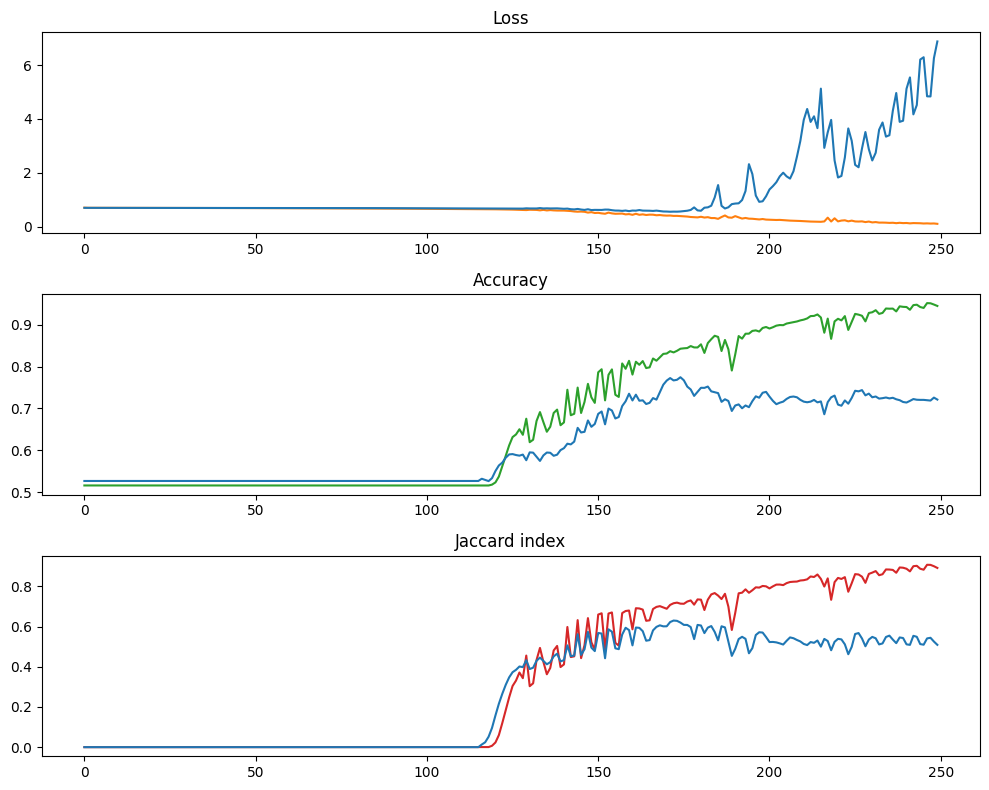

In [99]:
plt.figure(figsize=(10, 8))

plt.subplot(3,1,1)
plt.plot(range(EPOCHS), loss_dict["train"], color='C1')
plt.plot(range(EPOCHS), loss_dict["test"], color='C0')

plt.title("Loss")

plt.subplot(3,1,2)
plt.plot(range(EPOCHS), accuracy_dict["train"], color='C2')
plt.plot(range(EPOCHS), accuracy_dict["test"], color='C0')

plt.title("Accuracy")

plt.subplot(3,1,3)
plt.plot(range(EPOCHS), jaccard_dict["train"], color='C3')
plt.plot(range(EPOCHS), jaccard_dict["test"], color='C0')


plt.title("Jaccard index")
plt.tight_layout()

plt.show()

Анализ метрик обучения указывает на переобучение модели. Наблюдается устойчивое снижение функции потерь на тренировочных данных при одновременном росте потерь на валидационной выборке, что является характерным признаком переобучения.

# TopN

Рассмотрим изображения, на которых модель показывает худшие результаты.

In [ ]:
def show_jaccard_worst(net, loader, n: int):
    net.eval()
    device = next(net.parameters()).device
    
    samples = []
    
    with torch.no_grad():
        for data in loader:
            x = data['image'].to(device).float()
            y = data['mask'].to(device).float()
            
            preds = net(x)
            batch_jaccard = jaccard_index(preds, y)
            
            for i in range(x.size(0)):
                samples.append({
                    'pred': preds[i],
                    'mask': y[i],
                    'image': x[i],
                    'score': batch_jaccard if n == 1 else jaccard_index(preds[i:i+1], y[i:i+1])
                })
    
    samples.sort(key=lambda x: x['score'])
    worst_samples = samples[:n]
    
    fig, axs = plt.subplots(3, n, figsize=(n*3, 6), squeeze=False)
    titles = ['Prediction', 'Mask', 'Image']
    
    for i, sample in enumerate(worst_samples):
        axs[0,i].imshow(sample['pred'][0].cpu().sigmoid() > 0.5, cmap='gray')
        axs[1,i].imshow(sample['mask'][0].cpu(), cmap='gray')
        axs[2,i].imshow(sample['image'].permute(1,2,0).cpu())
        
        for j in range(3):
            axs[j,i].set_title(titles[j] if i == 0 else "")
            axs[j,i].axis('off')
    
    plt.tight_layout()
    plt.show()

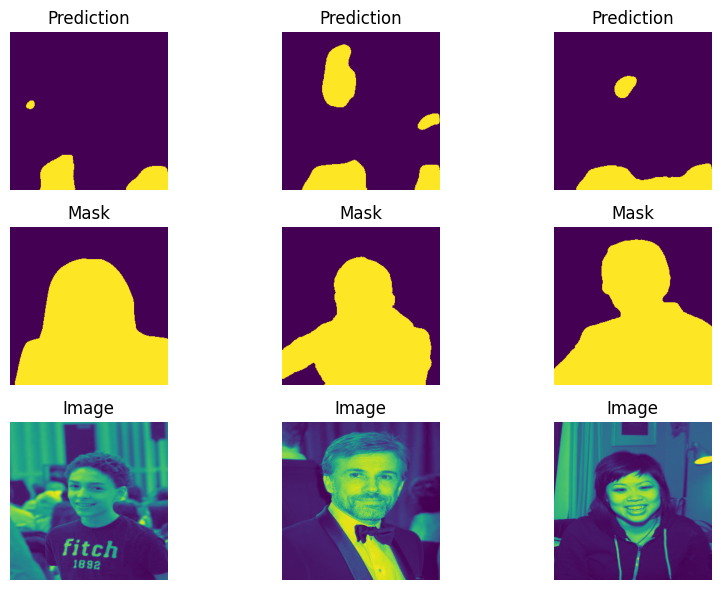

In [ ]:
show_jaccard_worst(net, test_loader, 3)

# Выбор оптимального времени обучения

Для выявления оптимальной продолжительности обучения проведем серию экспериментов с фиксированными гиперпараметрами, определяя момент, когда модель достигает достаточной точности до наступления переобучения.

In [ ]:
jaccard_dict = {"train": [], "test": []}

EPOCHS = [1, 10, 50, 100, 200, 300]

for epochs_num in tqdm(EPOCHS):
  net = UNET(3, 16, 1)
  criterion = nn.BCEWithLogitsLoss()
  optimizer = optim.Adam(net.parameters(), lr=3e-4)

  net = net.cuda()

  torch.cuda.empty_cache()

  for epoch in range(epochs_num):
      val_loss = 0.0
      for i, data in enumerate(train_loader, 0):
          x = data['image']
          y = data['mask']

          optimizer.zero_grad()
          outputs = net(x.cuda().float())

          loss = criterion(outputs, y.cuda().float())
          val_loss += loss.item()
          loss.backward()
          optimizer.step()

  jaccard_dict["train"].append(jaccard_index(net, train_loader))
  jaccard_dict["test"].append(jaccard_index(net, test_loader))

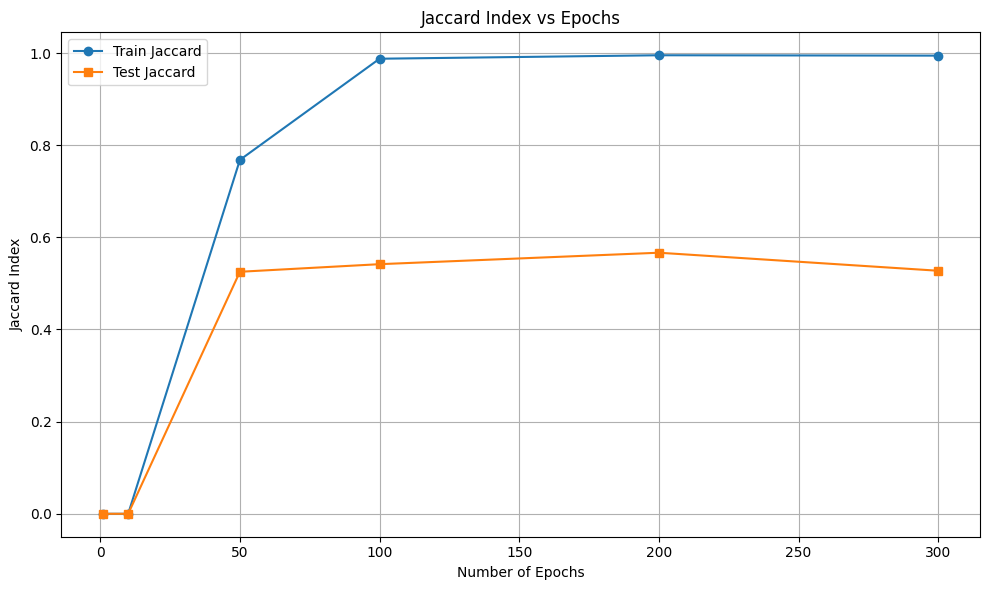

In [111]:
plt.figure(figsize=(10, 6))

plt.plot(EPOCHS, jaccard_dict["train"], label='Train Jaccard', marker='o')
plt.plot(EPOCHS, jaccard_dict["test"], label='Test Jaccard', marker='s')

plt.xlabel("Number of Epochs")
plt.ylabel("Jaccard Index")
plt.title("Jaccard Index vs Epochs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Анализ кривой обучения позволяет определить 100 эпох в качестве оптимального параметра для данного датасета, учитывая отсутствие существенного улучшения метрик при продолжении обучения.

# Аугментации

Попробуем повысить качество модели, не изменяя её архитектуру, за счёт добавления аугментаций данных.

In [ ]:
aug = A.Compose([
    A.RandomRotate90(),
    A.RandomCrop(200,200),
    A.RGBShift(r_shift_limit=100, g_shift_limit=100, b_shift_limit=100, p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.Resize(height=256, width=256, p=1)
])

In [ ]:
aug_data = PeopleDataset(DATASET, aug)[:1500]

train_dataset, test_dataset = torch.utils.data.random_split(aug_data, [1000, 500], generator=torch.Generator().manual_seed(42))

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=True, num_workers=2)

Shape: torch.Size([3, 256, 256])


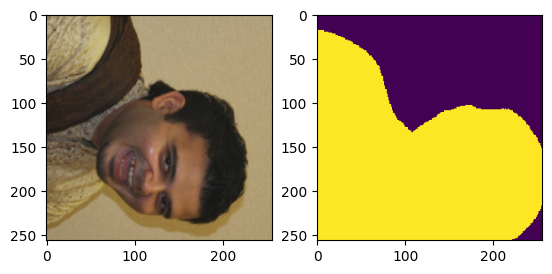

In [ ]:
_, axarr = plt.subplots(1,2)

i = Random().randint(0, len(aug_data)-1)

print(f"Shape: {aug_data[i]['image'].shape}")

axarr[0].imshow(aug_data[i]["image"].permute(1, 2, 0).detach().cpu().numpy())
axarr[1].imshow(aug_data[i]["mask"].permute(1, 2, 0))

plt.show()

Обучение модели и замер метрик.

In [ ]:
net = UNET(3, 16, 1)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(net.parameters(), lr=3e-4)

net = net.cuda()

torch.cuda.empty_cache()

accuracy_dict = {"train": [], "test": []}
jaccard_dict = {"train": [], "test": []}
loss_dict = {"train": [], "test": []}

EPOCHS = 200

for epoch in tqdm(range(EPOCHS)):
    for i, data in enumerate(train_loader, 0):
        x = data['image']
        y = data['mask']

        optimizer.zero_grad()
        outputs = net(x.cuda().float())

        loss = criterion(outputs, y.cuda().float())
        loss.backward()
        optimizer.step()

    accuracy_dict["test"].append(accuracy(net, test_loader))
    jaccard_dict["test"].append(jaccard_index(net, test_loader))
    loss_dict["train"].append(calc_loss(net, test_loader))

Accuracy: 0.7351651191711426, Jaccard: 0.6654310291968993


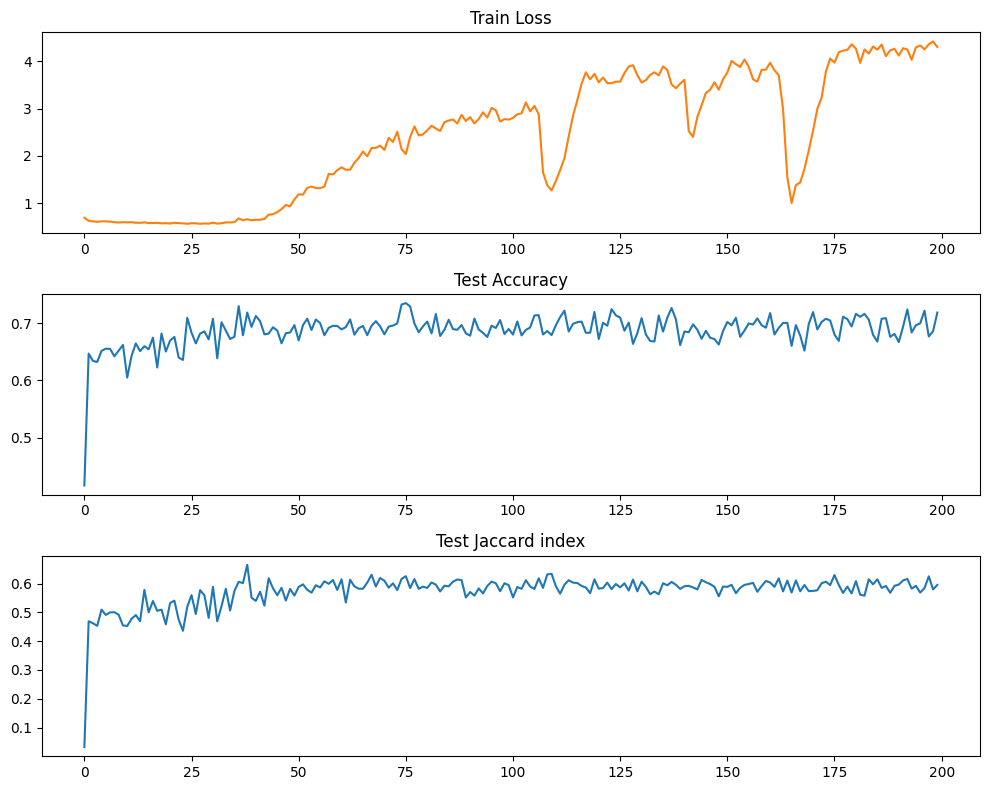

In [ ]:
print(f"Accuracy: {max(accuracy_dict['test'])}, Jaccard: {max(jaccard_dict['test'])}")

plt.figure(figsize=(10, 8))

plt.style.use('seaborn')

plt.subplot(3, 1, 1)
plt.plot(loss_dict["train"], color='C1', linewidth=2.5, alpha=0.8)
plt.title("Train Loss", fontsize=12, pad=10)

plt.subplot(3, 1, 2)
plt.plot(accuracy_dict["test"], color='C0', linewidth=2.5, alpha=0.8)
plt.title("Test Accuracy", fontsize=12, pad=10)

plt.subplot(3, 1, 3)
plt.plot(jaccard_dict["test"], color='C0', linewidth=2.5, alpha=0.8)
plt.title("Test Jaccard Index", fontsize=12, pad=10)

plt.tight_layout()
plt.show()

В результате удалось добиться улучшения ключевых метрик.

# Модифицированная архитектура модели

Попробуем изменить классы добавив:
* Дополнительные 1×1 свертки с активацией ReLU
* Dropout-слои в каждый блок для снижения переобучения
* Дополнительные слои на начальных этапах

In [ ]:
class CNNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super(CNNBlock, self).__init__()

        self.seq_block = nn.Sequential(
            nn.Conv2d(
                in_channels, out_channels, kernel_size, stride, padding, bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.3),
            nn.Conv2d(out_channels, out_channels, kernel_size=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.seq_block(x)


class CNNBlocks(nn.Module):
    def __init__(self, n_conv, in_channels, out_channels, padding=1):
        super(CNNBlocks, self).__init__()

        self.layers = nn.ModuleList()

        for i in range(n_conv):
            self.layers.append(CNNBlock(in_channels, out_channels, padding=padding))
            in_channels = out_channels

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x


class Encoder(nn.Module):
    def __init__(self, in_channels, out_channels, padding=1, n_down=4):
        super(Encoder, self).__init__()

        self.enc_layers = nn.ModuleList()

        for _ in range(n_down):
            self.enc_layers += [
                CNNBlocks(
                    n_conv=2,
                    in_channels=in_channels,
                    out_channels=out_channels,
                    padding=padding,
                ),
                nn.MaxPool2d(2, 2),
            ]
            in_channels = out_channels
            out_channels = 2 * out_channels

        self.enc_layers.append(
            CNNBlocks(
                n_conv=2,
                in_channels=in_channels,
                out_channels=out_channels,
                padding=padding,
            )
        )

    def forward(self, x):
        connections = []

        for layer in self.enc_layers:
            if isinstance(layer, CNNBlocks):
                x = layer(x)
                connections.append(x)
            else:
                x = layer(x)

        return x, connections


class Decoder(nn.Module):
    def __init__(self, in_channels, out_channels, exit_channels, padding=1, n_up=4):
        super(Decoder, self).__init__()

        self.exit_channels = exit_channels
        self.layers = nn.ModuleList()

        for i in range(n_up):
            self.layers += [
                nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2),
                CNNBlocks(
                    n_conv=2,
                    in_channels=in_channels,
                    out_channels=out_channels,
                    padding=padding,
                ),
            ]

            in_channels //= 2
            out_channels //= 2

        self.layers.append(
            nn.Conv2d(in_channels, self.exit_channels, kernel_size=1, padding=0)
        )

    def forward(self, x, connections):
        connections.pop(-1)
        for layer in self.layers:
            if isinstance(layer, CNNBlocks):
                connections_current = connections.pop(-1)
                x = torch.cat([x, connections_current], dim=1)
                x = layer(x)
            else:
                x = layer(x)
        return x


class UNET(nn.Module):
    def __init__(
        self, in_channels, first_out_channels, exit_channels, n_down=4, padding=1
    ):
        super(UNET, self).__init__()
        self.encoder = Encoder(
            in_channels, first_out_channels, padding=padding, n_down=n_down
        )
        self.decoder = Decoder(
            first_out_channels
            * (2**n_down),
            first_out_channels
            * (2 ** (n_down - 1)),
            exit_channels,
            padding=padding,
            n_up=n_down,
        )

    def forward(self, x):
        enc_out, connections = self.encoder(x)
        return self.decoder(enc_out, connections)

class JaccardLoss(nn.Module):
    def __init__(self, weight=None, size_average=True):
        super(JaccardLoss, self).__init__()

    def forward(self, inputs, targets, smooth=1):

        inputs = inputs.view(-1)
        targets = targets.view(-1)

        intersection = (inputs * targets).sum()
        total = (inputs + targets).sum()
        union = total - intersection

        IoU = (intersection + smooth)/(union + smooth)

        return 1 - IoU

class ComboLoss(nn.Module):
    def __init__(self, alpha=0.5):
        super().__init__()
        self.alpha = alpha
        self.bce = nn.BCEWithLogitsLoss()
        self.jaccard = JaccardLoss()

    def forward(self, inputs, targets):
        bce = self.bce(inputs, targets)
        jaccard = self.jaccard(torch.sigmoid(inputs), targets)
        return self.alpha * bce + (1 - self.alpha) * jaccard

In [ ]:
aug = A.Compose([
    A.RandomRotate90(),
    A.RandomCrop(200,200),
    A.RGBShift(r_shift_limit=100, g_shift_limit=100, b_shift_limit=100, p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.Resize(height=256, width=256, p=1)
])

aug_data = PeopleDataset(DATASET, aug)
train_dataset, test_dataset = torch.utils.data.random_split(aug_data, [1500, 500], generator=torch.Generator().manual_seed(42))
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=True, num_workers=2)

In [10]:
net = UNET(3, 16, 1)
criterion = ComboLoss()
optimizer = optim.Adam(net.parameters(), lr=3e-4)

net = net.cuda()

torch.cuda.empty_cache()

EPOCHS = 200

for epoch in tqdm(range(EPOCHS)):
    for i, data in enumerate(train_loader, 0):
        x = data['image']
        y = data['mask']

        optimizer.zero_grad()
        outputs = net(x.cuda().float())

        loss = criterion(outputs, y.cuda().float())
        loss.backward()
        optimizer.step()

print(f"Result accuracy: {accuracy(net, test_loader)}")
print(f"Result jaccard index: {jaccard_index(net, test_loader)}")

100%|██████████| 200/200 [42:01<00:00, 12.61s/it]


Result accuracy: 0.7328925132751465
Result jaccard index: 0.6115160139490924


В результате изменение архитектуры не дало видимых результатов. 
---

# 5Fold

Сравним качество модели, обученной стандартным способом, с результатами, полученными при помощи 5fold кросс-валидации.

100%|██████████| 50/50 [11:05<00:00, 13.30s/it]


Fold 0 Jaccard: 0.4209 Loss: 0.7132


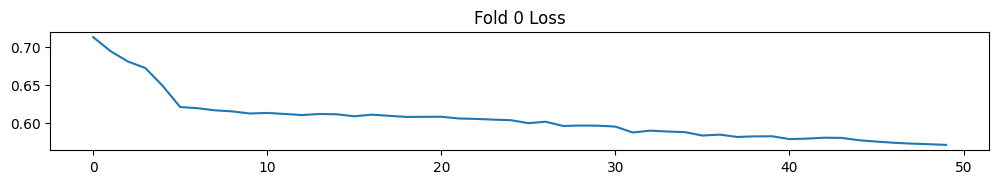

100%|██████████| 50/50 [11:17<00:00, 13.56s/it]


Fold 1 Jaccard: 0.4097 Loss: 0.6821


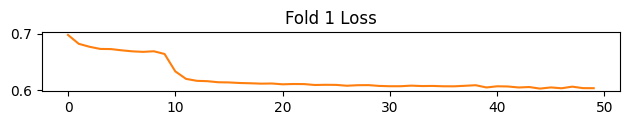

100%|██████████| 50/50 [11:13<00:00, 13.47s/it]


Fold 2 Jaccard: 0.5140 Loss: 0.6693


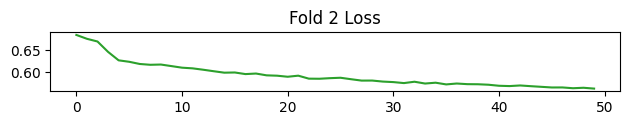

100%|██████████| 50/50 [11:18<00:00, 13.56s/it]


Fold 3 Jaccard: 0.4415 Loss: 0.6711


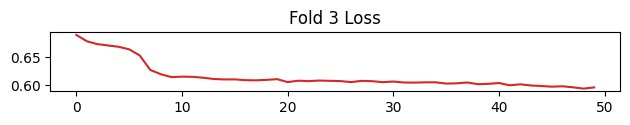

100%|██████████| 50/50 [11:28<00:00, 13.78s/it]


Fold 4 Jaccard: 0.4456 Loss: 0.6603


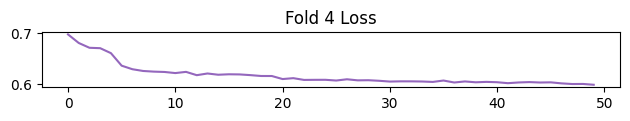

In [13]:
from sklearn.model_selection import KFold
from torch.utils.data import Subset

K = 5

dataset = PeopleDataset(DATASET, aug)

kfold = KFold(n_splits=K, shuffle=True, random_state=42)

plt.figure(figsize=(10, 8))
fold_metrics = []

for i, (train_index, test_index) in enumerate(kfold.split(dataset)):
    train_subset = Subset(dataset, train_index)
    test_subset = Subset(dataset, test_index)

    train_loader = DataLoader(train_subset, batch_size=32, shuffle=True, num_workers=2)
    test_loader = DataLoader(test_subset, batch_size=32, shuffle=True, num_workers=2)

    net = UNET(3, 16, 1)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(net.parameters(), lr=3e-4)

    net = net.cuda()

    torch.cuda.empty_cache()

    EPOCHS = 50

    loss_results = []

    for epoch in tqdm(range(EPOCHS)):
        val_loss = 0.0

        for _, data in enumerate(train_loader, 0):
            x = data['image']
            y = data['mask']

            optimizer.zero_grad()
            outputs = net(x.cuda().float())

            loss = criterion(outputs, y.cuda().float())
            val_loss += loss.item()
            loss.backward()
            optimizer.step()


        loss_results.append(val_loss / len(train_loader))

    jaccard = jaccard_index(net, test_loader)
    print(f"Fold {i} Jaccard: {jaccard:.4f} Loss: {loss_results[i]:.4f}")
    fold_metrics.append(jaccard)
    
    plt.subplot(K,1,i+1)
    plt.plot(range(EPOCHS), loss_results, color=f'C{i}')

    plt.title(f"Fold {i} Loss")

    plt.tight_layout()
    plt.show()

In [14]:
print(f"Max jaccard: {np.max(fold_metrics)}")
print(f"Mean jaccard: {np.mean(fold_metrics)}")

Max jaccard: 0.5139646249061158
Mean jaccard: 0.4463216947138333


# Анализ результатов 

Результаты, полученные на различных фолдах, демонстрируют согласованность с метриками стандартного обучения. Это свидетельствует о:

- Способности модели к генерализации на новых данных
- Отсутствии значимого переобучения
- Стабильности предсказательной способности модели